In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('nepal_house_data.csv')

In [4]:
df.head(3)

,location,land_area_sqft,floors,bedrooms,bathrooms,windows,doors,cement_bags,rcc_structure,plumbing,electricity,land_cost,construction_cost,material_cost,total_price
0,Chitwan,1055,1,5,4,13,4,238,1,1,0,6857500,1899000,167460,9043960
1,Dhangadi,2779,2,6,3,9,8,253,1,1,1,15284500,10004400,181760,25670660
2,Pokhara,2018,1,6,2,11,8,405,1,0,0,18162000,3632400,252600,22047000


In [5]:
df['location'].unique()

array(['Chitwan', 'Dhangadi', 'Pokhara', 'Syangja', 'Kathmandu'],
      dtype=object)

In [6]:
df.isnull().sum()

location             0
land_area_sqft       0
floors               0
bedrooms             0
bathrooms            0
windows              0
doors                0
cement_bags          0
rcc_structure        0
plumbing             0
electricity          0
land_cost            0
construction_cost    0
material_cost        0
total_price          0
dtype: int64

In [7]:
from sklearn.preprocessing import OneHotEncoder

In [8]:
df.dtypes

location             object
land_area_sqft        int64
floors                int64
bedrooms              int64
bathrooms             int64
windows               int64
doors                 int64
cement_bags           int64
rcc_structure         int64
plumbing              int64
electricity           int64
land_cost             int64
construction_cost     int64
material_cost         int64
total_price           int64
dtype: object

In [9]:
df['location'] = df['location'].astype(str)

In [10]:
encoder = OneHotEncoder()

In [12]:
encoded = encoder.fit_transform(df[['location']])

In [13]:
df['location']

0        Chitwan
1       Dhangadi
2        Pokhara
3        Pokhara
4        Pokhara
         ...    
995    Kathmandu
996    Kathmandu
997      Pokhara
998      Chitwan
999     Dhangadi
Name: location, Length: 1000, dtype: object

In [14]:
df[['location']]

,location
0,Chitwan
1,Dhangadi
2,Pokhara
3,Pokhara
4,Pokhara
...,...
995,Kathmandu
996,Kathmandu
997,Pokhara
998,Chitwan


In [15]:
df = pd.get_dummies(df, columns=["location"])

In [16]:
df.head()

,land_area_sqft,floors,bedrooms,bathrooms,windows,doors,cement_bags,rcc_structure,plumbing,electricity,land_cost,construction_cost,material_cost,total_price,location_Chitwan,location_Dhangadi,location_Kathmandu,location_Pokhara,location_Syangja
0,1055,1,5,4,13,4,238,1,1,0,6857500,1899000,167460,9043960,True,False,False,False,False
1,2779,2,6,3,9,8,253,1,1,1,15284500,10004400,181760,25670660,False,True,False,False,False
2,2018,1,6,2,11,8,405,1,0,0,18162000,3632400,252600,22047000,False,False,False,True,False
3,727,4,4,4,5,3,392,1,1,1,6543000,5234400,198640,12176040,False,False,False,True,False
4,1447,4,1,4,14,6,221,1,1,1,13023000,10418400,174820,23816220,False,False,False,True,False


In [17]:
X = df.drop("total_price", axis=1)
y = df["total_price"]

In [20]:
X = X.drop(['land_cost', 'construction_cost', 'material_cost'], axis=1)

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:

from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [25]:
y_pred = knn.predict(X_test)
from sklearn.metrics import mean_absolute_error, r2_score
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 3757085.1
R2 Score: 0.7804343003921492


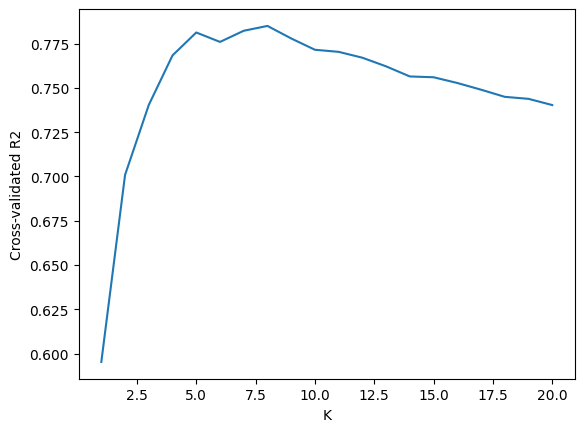

In [26]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsRegressor

errors = []

for k in range(1, 21):
    knn = KNeighborsRegressor(n_neighbors=k)
    score = cross_val_score(knn, X_train, y_train, cv=5, scoring='r2').mean()
    errors.append(score)

plt.plot(range(1, 21), errors)
plt.xlabel("K")
plt.ylabel("Cross-validated R2")
plt.show()

In [27]:
import joblib

# Save KNN model
joblib.dump(knn, "knn_model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [28]:
import joblib

# Make sure your model is fitted first
knn.fit(X_train, y_train)

# Save the fitted model
joblib.dump(knn, "knn_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [29]:
knn_loaded = joblib.load("knn_model.pkl")
y_pred = knn_loaded.predict(X_test)  # should work without errors